# Pendahuluan

Analisis emosi pada teks merupakan salah satu tugas penting dalam bidang Natural Language Processing (NLP), khususnya dalam memahami ekspresi perasaan manusia melalui media digital seperti media sosial. Platform seperti Twitter menjadi sumber data yang sangat kaya karena pengguna sering mengekspresikan emosi mereka secara langsung melalui teks. Namun, karakteristik teks pada Twitter yang cenderung pendek, tidak terstruktur, dan penuh dengan bahasa informal menjadikan tugas klasifikasi emosi menjadi lebih menantang.

Pada mini project ini, dilakukan klasifikasi emosi pada dataset **Indonesian Twitter Emotion Dataset** yang terdiri dari 4.403 tweet dengan lima kategori emosi, yaitu *love, anger, sadness, joy,* dan *fear*. Pendekatan yang digunakan dalam penelitian ini adalah **sequence model berbasis deep learning**, yaitu SimpleRNN, LSTM, GRU, dan Bidirectional GRU (BiGRU). Model-model ini dipilih karena kemampuannya dalam menangkap informasi berurutan pada data teks.

Selain itu, hasil dari model yang dibangun akan dibandingkan dengan penelitian sebelumnya yang menggunakan pendekatan machine learning klasik berbasis feature engineering. Perbandingan ini bertujuan untuk memahami kelebihan dan kekurangan masing-masing pendekatan, khususnya dalam konteks dataset berukuran kecil.

Melalui eksperimen ini, diharapkan dapat diperoleh pemahaman yang lebih mendalam mengenai:
- Pengaruh arsitektur sequence model terhadap performa klasifikasi emosi
- Perbedaan pendekatan deep learning dan machine learning klasik
- Tantangan dalam menangani data teks berbahasa Indonesia yang bersifat informal

---

# Anggota Kelompok

- Umar Al Faris - 5054241015  
- Muhammad Hadidan Nurhaunan - 5054241016  
- Wayan Raditya Putra - 5054241029  
- Syauqi Nabil Tasri - 5054241040  
- Arvito Rajapandya Natlysandro - 5054241046  

## A. Traning model Deep Learning (Sequence) untuk klasifikasi emosi pada dataset twitter indonesia

In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/wayanradityaputra/dataset-twitter-klasifikasi-emosi/Twitter_Emotion_Dataset.csv
/kaggle/input/datasets/wayanradityaputra/dataset-twitter-klasifikasi-emosi/kamus_singkatan.csv


In [6]:
# Import libraries
import pandas as pd
import numpy as np

# Define dataset paths
DATA_PATH = "/kaggle/input/datasets/wayanradityaputra/dataset-twitter-klasifikasi-emosi/Twitter_Emotion_Dataset.csv"
SLANG_PATH = "/kaggle/input/datasets/wayanradityaputra/dataset-twitter-klasifikasi-emosi/kamus_singkatan.csv"

# Load datasets
df = pd.read_csv(DATA_PATH)
slang_df = pd.read_csv(SLANG_PATH)

# Display basic preview
print("Preview dataset utama:")
display(df.head())

print("Preview kamus singkatan:")
display(slang_df.head())

# Check dataset shape
print("Ukuran dataset utama:", df.shape)
print("Ukuran kamus singkatan:", slang_df.shape)

# Check column names
print("Kolom dataset utama:")
print(df.columns.tolist())

print("Kolom kamus singkatan:")
print(slang_df.columns.tolist())

# Check basic info
print("Info dataset utama:")
df.info()

# Check missing values
print("Missing values dataset utama:")
display(df.isnull().sum())

print("Missing values kamus singkatan:")
display(slang_df.isnull().sum())

# Check duplicate rows
print("Jumlah duplikat dataset utama:", df.duplicated().sum())

# Check label distribution
label_col = "label"

if label_col in df.columns:
    print("Distribusi label:")
    display(df[label_col].value_counts())

    print("Distribusi label dalam persen:")
    display((df[label_col].value_counts(normalize=True) * 100).round(2))
else:
    print(f"Kolom '{label_col}' tidak ditemukan. Cek nama kolom label secara manual.")

# Detect text column candidate
print("Contoh isi setiap kolom object:")
for col in df.select_dtypes(include="object").columns:
    print(f"\nKolom: {col}")
    display(df[col].head())

Preview dataset utama:


,label,tweet
0,anger,"Soal jln Jatibaru,polisi tdk bs GERTAK gubernu..."
1,anger,"Sesama cewe lho (kayaknya), harusnya bisa lebi..."
2,happy,Kepingin gudeg mbarek Bu hj. Amad Foto dari go...
3,anger,"Jln Jatibaru,bagian dari wilayah Tn Abang.Peng..."
4,happy,"Sharing pengalaman aja, kemarin jam 18.00 bata..."


Preview kamus singkatan:


,aamiin;amin
0,adek;adik
1,adlh;adalah
2,aer;air
3,aiskrim;es krim
4,aj;saja


Ukuran dataset utama: (4401, 2)
Ukuran kamus singkatan: (1308, 1)
Kolom dataset utama:
['label', 'tweet']
Kolom kamus singkatan:
['aamiin;amin ']
Info dataset utama:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4401 entries, 0 to 4400
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   4401 non-null   object
 1   tweet   4401 non-null   object
dtypes: object(2)
memory usage: 68.9+ KB
Missing values dataset utama:


...

label
anger      25.02
happy      23.11
sadness    22.65
fear       14.75
love       14.47
Name: proportion, dtype: float64

Contoh isi setiap kolom object:

Kolom: label


0    anger
1    anger
2    happy
3    anger
4    happy
Name: label, dtype: object


Kolom: tweet


0    Soal jln Jatibaru,polisi tdk bs GERTAK gubernu...
1    Sesama cewe lho (kayaknya), harusnya bisa lebi...
2    Kepingin gudeg mbarek Bu hj. Amad Foto dari go...
3    Jln Jatibaru,bagian dari wilayah Tn Abang.Peng...
4    Sharing pengalaman aja, kemarin jam 18.00 bata...
Name: tweet, dtype: object

In [7]:
# Membuat dictionary slang_dict untuk menjadi kamus translasi dari slang ke bahasa yang baik dan benar

slang_df = pd.read_csv(SLANG_PATH, sep=";", header=None, names=["slang", "normal"])
slang_dict = dict(zip(slang_df["slang"], slang_df["normal"]))

print(slang_dict.get("adlh"))
print(slang_dict.get("gk"))
print(slang_dict.get("bgt"))


adalah 
tidak
sangat 


In [8]:
# Data cleaning function

import re

def clean_text(text, slang_dict):
    # Convert non-string value to empty string
    if not isinstance(text, str):
        return ""

    # Lowercase text
    text = text.lower()

    # Remove special placeholder tokens
    text = re.sub(r"\[username\]|\[url\]|\[sensitive-no\]", " ", text)

    # Remove punctuation and symbols, keep letters, numbers, and spaces
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)

    # Remove extra whitespace before tokenization
    text = re.sub(r"\s+", " ", text).strip()

    # Normalize slang word by word
    tokens = text.split()
    tokens = [slang_dict.get(token, token) for token in tokens]

    # Join tokens back into clean text
    text = " ".join(tokens)

    # Remove extra whitespace after normalization
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [9]:
sample_text = "[USERNAME] Aku gk suka bgt!!! [URL]"
print(clean_text(sample_text, slang_dict))

saya tidak suka sangat


In [10]:
df["clean_text"] = df["tweet"].apply(lambda x: clean_text(x, slang_dict))

display(df[["tweet", "clean_text", "label"]].head(10))

,tweet,clean_text,label
0,"Soal jln Jatibaru,polisi tdk bs GERTAK gubernu...",soal jalan jatibaru polisi tidak bisa gertak g...,anger
1,"Sesama cewe lho (kayaknya), harusnya bisa lebi...",sesama cewek lho kayaknya harusnya bisa lebih ...,anger
2,Kepingin gudeg mbarek Bu hj. Amad Foto dari go...,kepingin gudeg mbarek bu hj amad foto dari goo...,happy
3,"Jln Jatibaru,bagian dari wilayah Tn Abang.Peng...",jalan jatibaru bagian dari wilayah tn abang pe...,anger
4,"Sharing pengalaman aja, kemarin jam 18.00 bata...",sharing pengalaman saja kemarin jam 18 00 bata...,happy
5,"Dari sekian banyak thread yang aku baca, threa...",dari sekian banyak thread yang saya baca threa...,anger
6,Sharing sama temen tuh emg guna bgt. Disaat lu...,sharing sama teman tuh memang guna sangat disa...,happy
7,Orang lain kalau pake ponco itu buat jas hujan...,orang lain kalau pakai ponco itu buat jas huja...,sadness
8,"Contoh mereka yg gemar menyudutkan, teriak pal...",contoh mereka yang gemar menyudutkan teriak pa...,anger
9,Pulang udah H-4 lebaran dilema sekali. Seperti...,pulang sudah h 4 lebaran dilema sekali seperti...,sadness


In [11]:
print("Jumlah data kosong setelah cleaning:", (df["clean_text"] == "").sum())

display(df[df["clean_text"] == ""][["tweet", "clean_text", "label"]].head())

Jumlah data kosong setelah cleaning: 0


,tweet,clean_text,label


In [12]:
# Count number of words in each clean text
df["text_length"] = df["clean_text"].apply(lambda x: len(x.split()))

# Show basic statistics
display(df["text_length"].describe())

# Show useful percentiles
percentiles = [50, 75, 90, 95, 99]
display(df["text_length"].quantile([p / 100 for p in percentiles]))

count    4401.000000
mean       28.431038
std         9.497719
min         2.000000
25%        22.000000
50%        28.000000
75%        35.000000
max        83.000000
Name: text_length, dtype: float64

0.50    28.0
0.75    35.0
0.90    41.0
0.95    44.0
0.99    49.0
Name: text_length, dtype: float64

In [13]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Define tokenizer configuration
VOCAB_SIZE = 5000
OOV_TOKEN = "<OOV>"
MAX_LENGTH = 44
PADDING_TYPE = "post"
TRUNCATING_TYPE = "post"

# Create tokenizer
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token=OOV_TOKEN
)

# Fit tokenizer only on clean text
tokenizer.fit_on_texts(df["clean_text"])

# Convert text to sequence of integers
sequences = tokenizer.texts_to_sequences(df["clean_text"])

# Pad sequences to the same length
X = pad_sequences(
    sequences,
    maxlen=MAX_LENGTH,
    padding=PADDING_TYPE,
    truncating=TRUNCATING_TYPE
)

# Check result
print("Jumlah data:", len(sequences))
print("Shape X:", X.shape)

print("Contoh teks asli:")
print(df["clean_text"].iloc[0])

print("\nContoh sequence sebelum padding:")
print(sequences[0])

print("\nContoh sequence setelah padding:")
print(X[0])

2026-04-28 05:47:20.613724: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777355240.996736      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777355241.104213      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777355242.014532      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777355242.014575      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777355242.014578      55 computation_placer.cc:177] computation placer alr

Jumlah data: 4401
Shape X: (4401, 44)
Contoh teks asli:
soal jalan jatibaru polisi tidak bisa gertak gubernur emangny polisi tidak ikut pmbhasan jangan berpolitik pengaturan wilayah hak gubernur persoalan tn abang soal turun temurun pelik perlu kesabaran

Contoh sequence sebelum padding:
[298, 116, 4897, 718, 4, 17, 1, 654, 1, 718, 4, 239, 1, 54, 4898, 4899, 2128, 780, 654, 1662, 4900, 655, 298, 656, 1, 1, 256, 1167]

Contoh sequence setelah padding:
[ 298  116 4897  718    4   17    1  654    1  718    4  239    1   54
 4898 4899 2128  780  654 1662 4900  655  298  656    1    1  256 1167
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]


In [14]:
# Check vocabulary size
word_index = tokenizer.word_index

print("Total unique words:", len(word_index))
print("Top 20 words:")
print(list(word_index.items())[:20])

Total unique words: 18632
Top 20 words:
[('<OOV>', 1), ('yang', 2), ('saya', 3), ('tidak', 4), ('dan', 5), ('di', 6), ('sudah', 7), ('ini', 8), ('itu', 9), ('kalau', 10), ('kamu', 11), ('ada', 12), ('sama', 13), ('tapi', 14), ('saja', 15), ('ya', 16), ('bisa', 17), ('orang', 18), ('lagi', 19), ('jadi', 20)]


In [15]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Create label encoder
label_encoder = LabelEncoder()

# Convert text labels to integer labels
y_encoded = label_encoder.fit_transform(df["label"])

# Convert integer labels to one-hot vectors
y = to_categorical(y_encoded)

# Check label mapping
label_mapping = dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))
print("Label mapping:")
print(label_mapping)

# Check shapes
print("Shape X:", X.shape)
print("Shape y:", y.shape)

# Preview encoded labels
print("Original labels:")
print(df["label"].head().tolist())

print("\nEncoded labels:")
print(y_encoded[:5])

print("\nOne-hot labels:")
print(y[:5])

Label mapping:
{'anger': 0, 'fear': 1, 'happy': 2, 'love': 3, 'sadness': 4}
Shape X: (4401, 44)
Shape y: (4401, 5)
Original labels:
['anger', 'anger', 'happy', 'anger', 'happy']

Encoded labels:
[0 0 2 0 2]

One-hot labels:
[[1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]]


In [16]:
from sklearn.model_selection import train_test_split

# Split data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (3520, 44)
X_val: (881, 44)
y_train: (3520, 5)
y_val: (881, 5)


In [17]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Define model configuration
EMBEDDING_DIM = 64
RNN_UNITS = 64
NUM_CLASSES = 5

In [18]:
# Build baseline SimpleRNN model
model_rnn = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LENGTH
    ),
    SimpleRNN(RNN_UNITS),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation="softmax")
])

# Compile model
model_rnn.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# Show model architecture
model_rnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1777355273.934848      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777355273.940738      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Define early stopping to reduce overfitting
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Train model
history_rnn = model_rnn.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/20


I0000 00:00:1777355275.637233     129 service.cc:152] XLA service 0x7f645c005110 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777355275.637309     129 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777355275.637316     129 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777355276.224467     129 cuda_dnn.cc:529] Loaded cuDNN version 91002


 31/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2572 - loss: 1.6099

I0000 00:00:1777355278.418735     129 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.2497 - loss: 1.5986 - val_accuracy: 0.2826 - val_loss: 1.5374
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4551 - loss: 1.3314 - val_accuracy: 0.3405 - val_loss: 1.4491
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7589 - loss: 0.7858 - val_accuracy: 0.3746 - val_loss: 1.5639
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9338 - loss: 0.3369 - val_accuracy: 0.3042 - val_loss: 1.9578
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9765 - loss: 0.1566 - val_accuracy: 0.4018 - val_loss: 1.9323


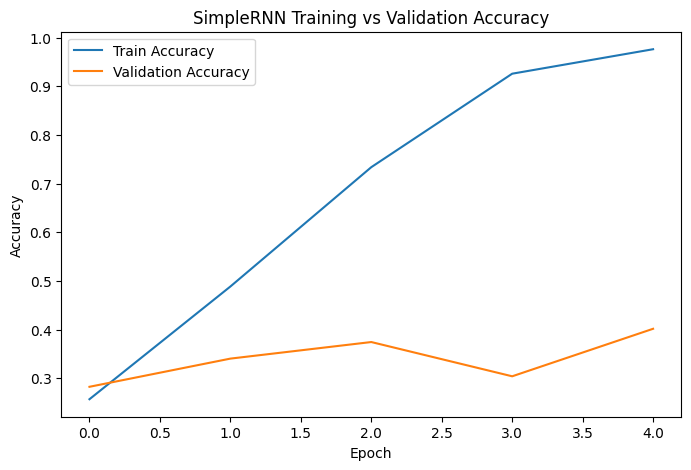

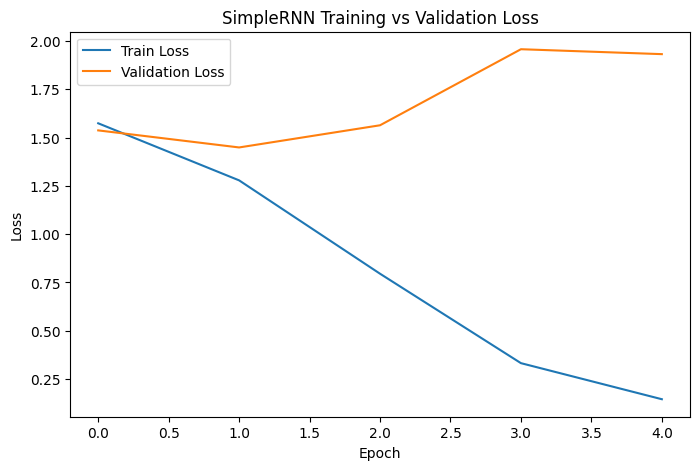

In [20]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(history_rnn.history["accuracy"], label="Train Accuracy")
plt.plot(history_rnn.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("SimpleRNN Training vs Validation Accuracy")
plt.legend()
plt.show()

# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history_rnn.history["loss"], label="Train Loss")
plt.plot(history_rnn.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SimpleRNN Training vs Validation Loss")
plt.legend()
plt.show()

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
Classification Report SimpleRNN:
              precision    recall  f1-score   support

       anger       0.35      0.49      0.41       220
        fear       0.25      0.16      0.20       130
       happy       0.30      0.28      0.29       204
        love       0.52      0.57      0.54       127
     sadness       0.26      0.21      0.23       200

    accuracy                           0.34       881
   macro avg       0.34      0.34      0.33       881
weighted avg       0.33      0.34      0.33       881



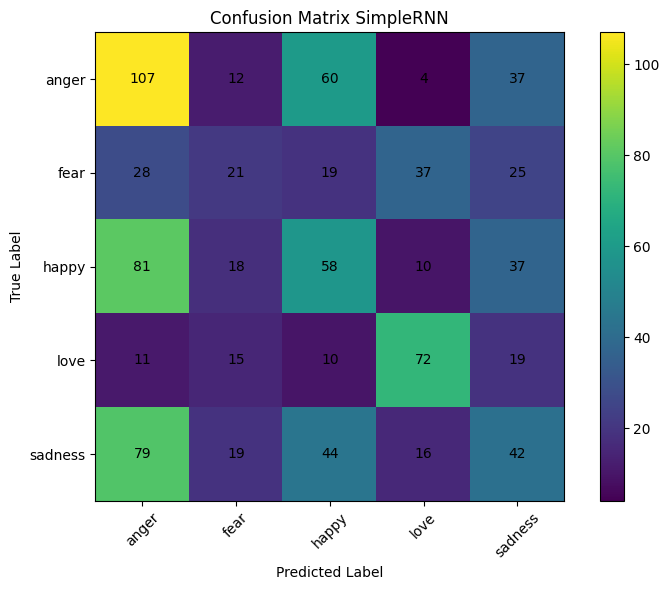

In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# Predict validation data
y_val_pred_prob = model_rnn.predict(X_val)
y_val_pred = np.argmax(y_val_pred_prob, axis=1)
y_val_true = np.argmax(y_val, axis=1)

# Get class names
class_names = label_encoder.classes_

# Classification report
print("Classification Report SimpleRNN:")
print(classification_report(y_val_true, y_val_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_val_true, y_val_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("Confusion Matrix SimpleRNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
plt.yticks(np.arange(len(class_names)), class_names)

# Show numbers inside cells
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

Model SimpleRNN menunjukkan performa yang rendah dengan accuracy sekitar 33%. 
Berdasarkan confusion matrix, model memiliki bias yang kuat terhadap kelas “happy”, 
di mana banyak data dari kelas lain seperti anger, sadness, dan love 
diprediksi sebagai happy.

Hal ini menunjukkan bahwa model belum mampu menangkap konteks emosi dengan baik, 
terutama untuk emosi yang bersifat lebih halus seperti fear dan sadness. 
Keterbatasan ini kemungkinan disebabkan oleh arsitektur SimpleRNN yang kurang mampu 
menangani dependency jangka panjang dalam sequence teks.

In [22]:
from tensorflow.keras.layers import LSTM

# Build LSTM model
model_lstm = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LENGTH
    ),
    LSTM(64),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation="softmax")
])

# Compile LSTM model
model_lstm.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# Train LSTM model
history_lstm = model_lstm.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.2540 - loss: 1.5910 - val_accuracy: 0.3065 - val_loss: 1.5179
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3534 - loss: 1.3963 - val_accuracy: 0.3655 - val_loss: 1.3525
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4036 - loss: 1.1929 - val_accuracy: 0.3905 - val_loss: 1.4112
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4816 - loss: 1.0926 - val_accuracy: 0.4086 - val_loss: 1.3528
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6052 - loss: 0.9280 - val_accuracy: 0.4120 - val_loss: 1.5067


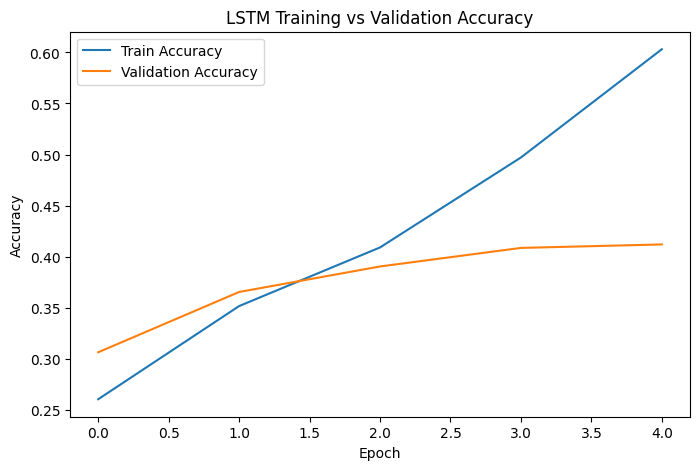

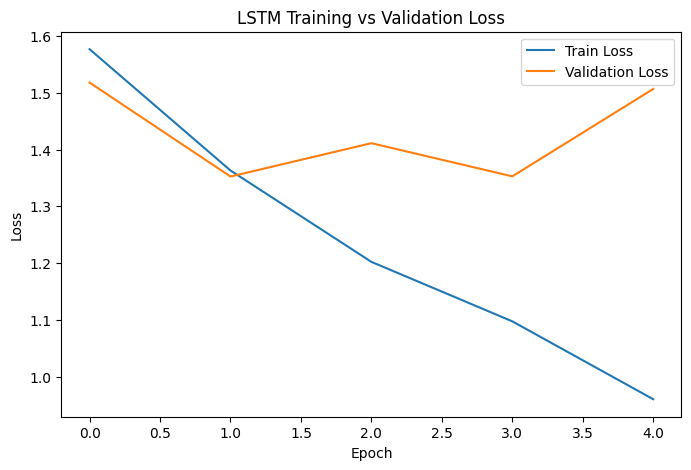

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Classification Report LSTM:
              precision    recall  f1-score   support

       anger       0.36      0.91      0.51       220
        fear       0.14      0.04      0.06       130
       happy       0.00      0.00      0.00       204
        love       0.42      0.78      0.55       127
     sadness       0.37      0.09      0.14       200

    accuracy                           0.37       881
   macro avg       0.26      0.36      0.25       881
weighted avg       0.25      0.37      0.25       881



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


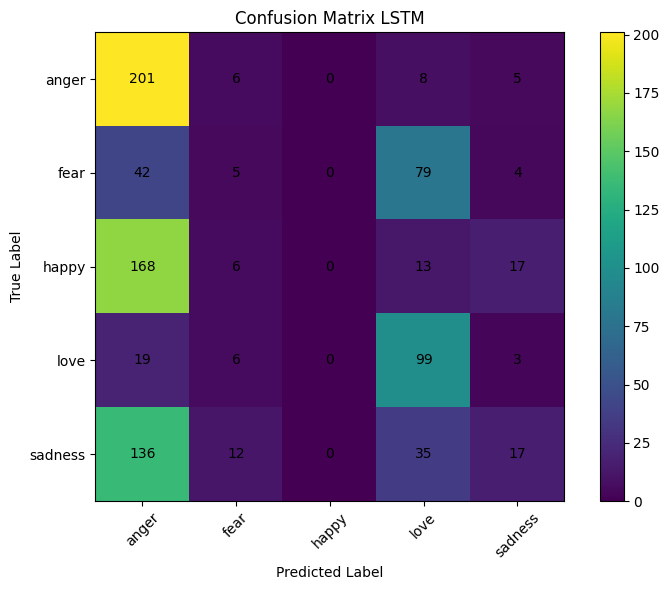

In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# Plot LSTM training and validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(history_lstm.history["accuracy"], label="Train Accuracy")
plt.plot(history_lstm.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Training vs Validation Accuracy")
plt.legend()
plt.show()

# Plot LSTM training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history_lstm.history["loss"], label="Train Loss")
plt.plot(history_lstm.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training vs Validation Loss")
plt.legend()
plt.show()

# Predict validation data
y_val_pred_prob_lstm = model_lstm.predict(X_val)
y_val_pred_lstm = np.argmax(y_val_pred_prob_lstm, axis=1)
y_val_true = np.argmax(y_val, axis=1)

# Get class names
class_names = label_encoder.classes_

# Classification report
print("Classification Report LSTM:")
print(classification_report(y_val_true, y_val_pred_lstm, target_names=class_names))

# Confusion matrix
cm_lstm = confusion_matrix(y_val_true, y_val_pred_lstm)

plt.figure(figsize=(8, 6))
plt.imshow(cm_lstm)
plt.title("Confusion Matrix LSTM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
plt.yticks(np.arange(len(class_names)), class_names)

# Show numbers inside cells
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm_lstm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

Model LSTM memperoleh akurasi validasi sekitar 37%, sedikit lebih tinggi dibandingkan SimpleRNN. Namun, berdasarkan classification report, performa model belum merata pada semua kelas. Model memiliki recall tinggi pada kelas anger dan love, tetapi gagal mengenali kelas happy dengan recall 0.00 serta masih sangat lemah pada kelas fear dan sadness. Hal ini menunjukkan bahwa meskipun LSTM memiliki mekanisme gate untuk menangkap konteks lebih baik daripada SimpleRNN, model masih mengalami bias prediksi terhadap kelas tertentu dan belum mampu melakukan generalisasi yang baik pada dataset yang relatif kecil.

In [25]:
from tensorflow.keras.layers import GRU

# Build GRU model
model_gru = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LENGTH
    ),
    GRU(64),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation="softmax")
])

# Compile GRU model
model_gru.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# Train GRU model
history_gru = model_gru.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.2485 - loss: 1.5925 - val_accuracy: 0.2497 - val_loss: 1.5850
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2451 - loss: 1.5833 - val_accuracy: 0.2497 - val_loss: 1.5851
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2534 - loss: 1.5784 - val_accuracy: 0.3019 - val_loss: 1.5511
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3923 - loss: 1.4104 - val_accuracy: 0.4835 - val_loss: 1.2363
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5568 - loss: 1.0569 - val_accuracy: 0.5062 - val_loss: 1.2624
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6891 - loss: 0.7984 - val_accuracy: 0.5880 - val_loss: 1.0944
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8415 - loss: 0.5050 - val_accuracy: 0.5834 - val_loss: 1.2253
Epoch 8/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9004 - loss: 0.3584 - val_accuracy: 0.5732 - val_

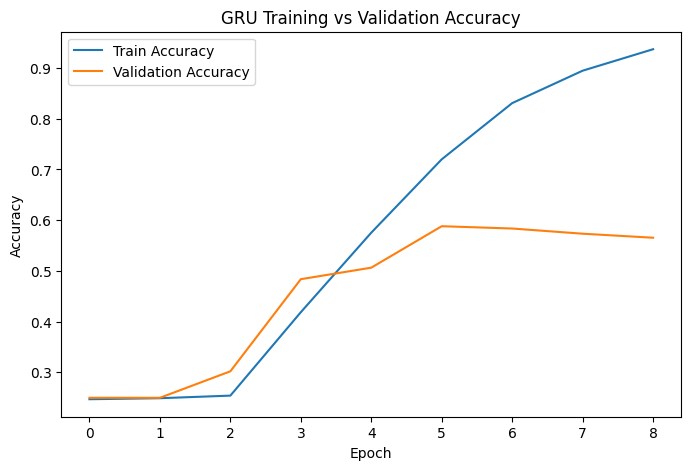

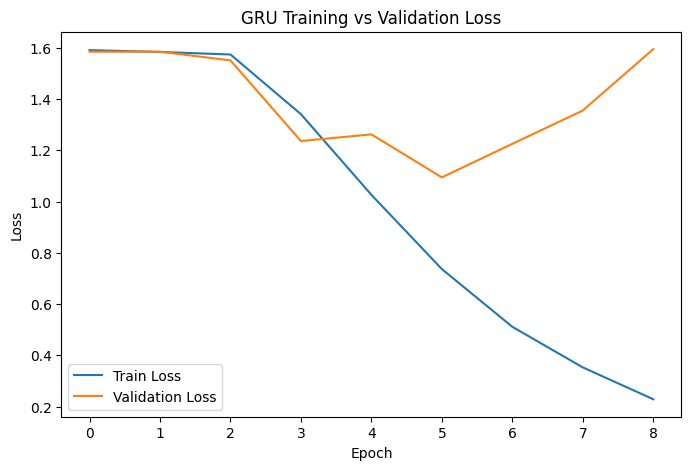

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Classification Report GRU:
              precision    recall  f1-score   support

       anger       0.60      0.75      0.67       220
        fear       0.80      0.58      0.68       130
       happy       0.62      0.49      0.55       204
        love       0.79      0.72      0.76       127
     sadness       0.37      0.43      0.40       200

    accuracy                           0.59       881
   macro avg       0.64      0.59      0.61       881
weighted avg       0.61      0.59      0.59       881



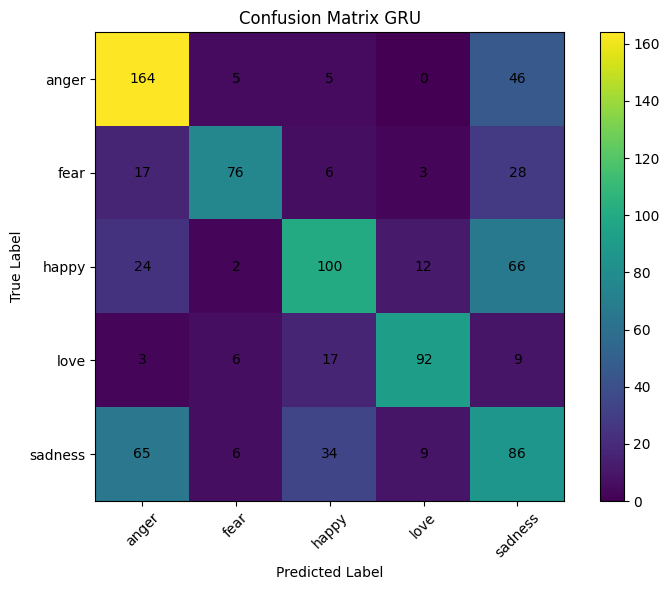

In [26]:
# Plot GRU training and validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(history_gru.history["accuracy"], label="Train Accuracy")
plt.plot(history_gru.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GRU Training vs Validation Accuracy")
plt.legend()
plt.show()

# Plot GRU training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history_gru.history["loss"], label="Train Loss")
plt.plot(history_gru.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GRU Training vs Validation Loss")
plt.legend()
plt.show()

# Predict validation data
y_val_pred_prob_gru = model_gru.predict(X_val)
y_val_pred_gru = np.argmax(y_val_pred_prob_gru, axis=1)

# Classification report
print("Classification Report GRU:")
print(classification_report(y_val_true, y_val_pred_gru, target_names=class_names))

# Confusion matrix
cm_gru = confusion_matrix(y_val_true, y_val_pred_gru)

plt.figure(figsize=(8, 6))
plt.imshow(cm_gru)
plt.title("Confusion Matrix GRU")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
plt.yticks(np.arange(len(class_names)), class_names)

# Show numbers inside cells
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm_gru[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

Model GRU menunjukkan performa terbaik dengan akurasi sekitar 59%, jauh lebih tinggi dibandingkan SimpleRNN (~33%) dan LSTM (~37%). Selain peningkatan akurasi, GRU juga menghasilkan performa yang lebih seimbang antar kelas. Hal ini terlihat dari nilai precision, recall, dan F1-score yang relatif tinggi pada sebagian besar kelas seperti anger, fear, dan love.

Kelebihan GRU dibandingkan LSTM dalam eksperimen ini diduga karena jumlah parameter yang lebih sedikit, sehingga lebih efektif dalam kondisi dataset yang relatif kecil. Sebaliknya, LSTM cenderung mengalami kesulitan dalam generalisasi dan menunjukkan bias terhadap beberapa kelas.

Namun, model masih mengalami kesulitan dalam membedakan kelas sadness, yang memiliki kemiripan semantik dengan kelas lain seperti anger dan fear.

In [27]:
model_results = {
    "SimpleRNN": {
        "accuracy": 0.33,
        "params": model_rnn.count_params()
    },
    "LSTM": {
        "accuracy": 0.37,
        "params": model_lstm.count_params()
    },
    "GRU": {
        "accuracy": 0.59,
        "params": model_gru.count_params()
    }
}

for model_name, result in model_results.items():
    print(model_name)
    print("Accuracy:", result["accuracy"])
    print("Parameters:", result["params"])
    print()

SimpleRNN
Accuracy: 0.33
Parameters: 328581

LSTM
Accuracy: 0.37
Parameters: 353349

GRU
Accuracy: 0.59
Parameters: 345285



GRU menjadi model terbaik pada eksperimen awal. Analisis awal menunjukkan bahwa GRU kemungkinan lebih cocok karena memiliki arsitektur lebih sederhana dibanding LSTM, tetapi tetap memiliki mekanisme gate untuk menjaga informasi penting dalam sequence. Dengan dataset yang relatif kecil, model yang lebih ringan dapat memberikan generalisasi yang lebih baik.

In [28]:
from tensorflow.keras.layers import Bidirectional, GRU

# Build Bidirectional GRU model
model_bigru = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LENGTH
    ),
    Bidirectional(GRU(64)),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation="softmax")
])

# Compile Bidirectional GRU model
model_bigru.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# Train Bidirectional GRU model
history_bigru = model_bigru.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.2582 - loss: 1.5824 - val_accuracy: 0.3678 - val_loss: 1.4948
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5107 - loss: 1.2674 - val_accuracy: 0.5789 - val_loss: 1.0518
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7283 - loss: 0.7457 - val_accuracy: 0.5846 - val_loss: 1.1319
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8443 - loss: 0.4749 - val_accuracy: 0.6050 - val_loss: 1.1974
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9079 - loss: 0.3152 - val_accuracy: 0.5766 - val_loss: 1.3417


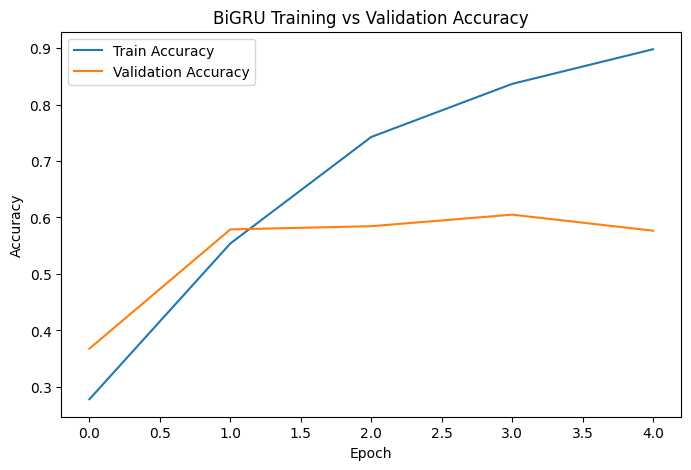

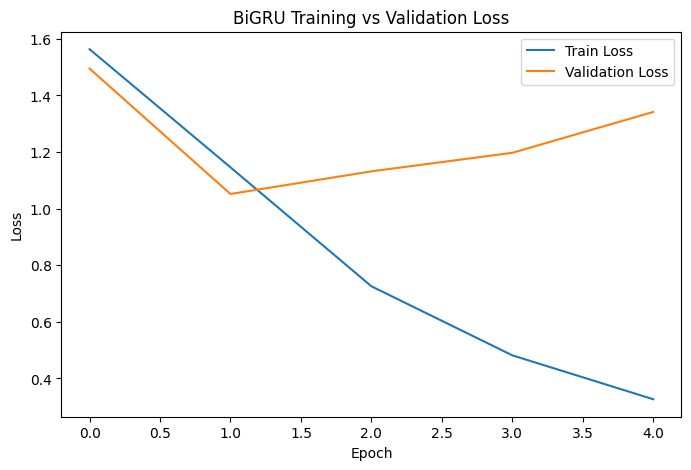

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Classification Report BiGRU:
              precision    recall  f1-score   support

       anger       0.66      0.68      0.67       220
        fear       0.77      0.58      0.66       130
       happy       0.49      0.71      0.58       204
        love       0.78      0.62      0.69       127
     sadness       0.39      0.30      0.34       200

    accuracy                           0.58       881
   macro avg       0.62      0.58      0.59       881
weighted avg       0.59      0.58      0.58       881



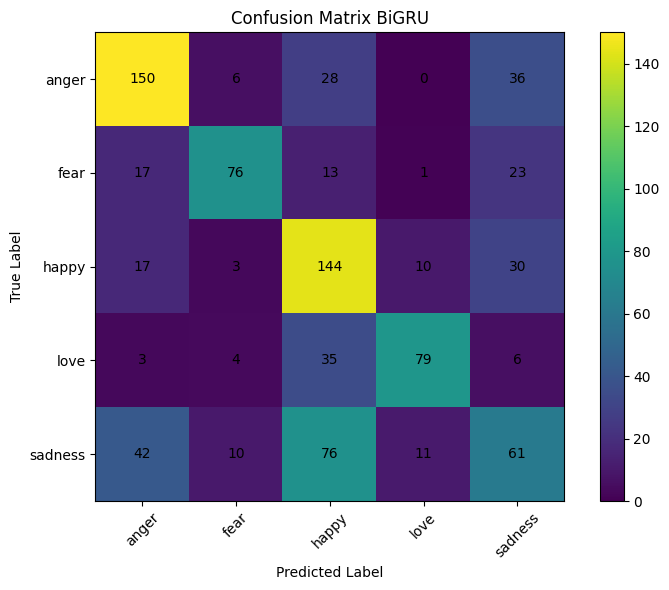

In [29]:
# Plot BiGRU training and validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(history_bigru.history["accuracy"], label="Train Accuracy")
plt.plot(history_bigru.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("BiGRU Training vs Validation Accuracy")
plt.legend()
plt.show()

# Plot BiGRU training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history_bigru.history["loss"], label="Train Loss")
plt.plot(history_bigru.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BiGRU Training vs Validation Loss")
plt.legend()
plt.show()

# Predict validation data
y_val_pred_prob_bigru = model_bigru.predict(X_val)
y_val_pred_bigru = np.argmax(y_val_pred_prob_bigru, axis=1)

# Classification report
print("Classification Report BiGRU:")
print(classification_report(y_val_true, y_val_pred_bigru, target_names=class_names))

# Confusion matrix
cm_bigru = confusion_matrix(y_val_true, y_val_pred_bigru)

plt.figure(figsize=(8, 6))
plt.imshow(cm_bigru)
plt.title("Confusion Matrix BiGRU")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
plt.yticks(np.arange(len(class_names)), class_names)

# Show numbers inside cells
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm_bigru[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

Model BiGRU memperoleh akurasi 58%, sedikit lebih rendah dibandingkan GRU sebesar 59%. Meskipun BiGRU mampu meningkatkan recall pada kelas happy, performa pada kelas sadness menurun. Hal ini menunjukkan bahwa penggunaan arsitektur bidirectional tidak selalu meningkatkan performa secara keseluruhan, terutama pada dataset berukuran kecil. Pada eksperimen ini, GRU dipilih sebagai model terbaik karena memiliki akurasi dan macro F1-score tertinggi.

In [30]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["SimpleRNN", "LSTM", "GRU", "BiGRU"],
    "Accuracy": [0.33, 0.37, 0.59, 0.58],
    "Macro F1": [0.29, 0.25, 0.61, 0.59],
    "Weighted F1": [0.33, 0.25, 0.59, 0.58],
    "Parameters": [
        model_rnn.count_params(),
        model_lstm.count_params(),
        model_gru.count_params(),
        model_bigru.count_params()
    ]
})

results

,Model,Accuracy,Macro F1,Weighted F1,Parameters
0,SimpleRNN,0.33,0.29,0.33,328581
1,LSTM,0.37,0.25,0.25,353349
2,GRU,0.59,0.61,0.59,345285
3,BiGRU,0.58,0.59,0.58,370565


Dari hasil eksperimen, model GRU menunjukkan performa terbaik dengan akurasi sebesar 59% dan macro F1-score sebesar 0.61. Model ini mampu mengungguli SimpleRNN dan LSTM secara signifikan, serta sedikit lebih baik dibandingkan BiGRU.

Model SimpleRNN menunjukkan performa terendah karena keterbatasannya dalam menangkap dependensi jangka panjang pada sequence. LSTM memberikan peningkatan dibandingkan SimpleRNN, namun belum optimal pada dataset berukuran kecil. GRU memberikan hasil terbaik karena memiliki arsitektur yang lebih sederhana dibandingkan LSTM, sehingga lebih stabil dan mampu melakukan generalisasi dengan lebih baik pada dataset terbatas. Sementara itu, BiGRU tidak memberikan peningkatan signifikan, yang menunjukkan bahwa kompleksitas tambahan tidak selalu berdampak positif.

## B. Membandingkan dengan Paper


Hasil eksperimen dibandingkan dengan penelitian sebelumnya menunjukkan bahwa model terbaik dalam eksperimen ini, yaitu GRU dengan macro F1-score sekitar 0.61, masih berada di bawah hasil yang dilaporkan dalam paper, yaitu sebesar 69.73% F1-score pada dataset yang sama.

Perbedaan performa ini disebabkan oleh perbedaan pendekatan yang digunakan. Penelitian dalam paper lebih menekankan pada feature engineering dengan menggabungkan berbagai fitur seperti Bag-of-Words, FastText embedding, lexicon-based features, POS tagging, dan orthographic features. Kombinasi fitur ini mampu meningkatkan representasi informasi secara signifikan.

Sebaliknya, model dalam eksperimen ini menggunakan pendekatan deep learning berbasis sequence model yang mengandalkan representasi teks secara end-to-end tanpa feature engineering tambahan. Selain itu, embedding yang digunakan dilatih dari nol pada dataset yang relatif kecil, sehingga representasi semantik yang dihasilkan tidak sekuat embedding yang digunakan dalam paper.

Dengan demikian, dapat disimpulkan bahwa pada dataset berukuran kecil, pendekatan machine learning klasik dengan feature engineering yang kuat masih dapat mengungguli model deep learning.